In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setting style for better-looking charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("COMBINED DATASET - EXPLORATORY ANALYSIS")
print("="*60)

# Loading combined dataset
df = pd.read_parquet('../data/processed/combined_dataset.parquet')

print(f"\nDataset loaded: {len(df):,} jobs")
print(f"Date range: {df['created'].min()} to {df['created'].max()}")
print(f"Categories: {df['category'].nunique()}")

COMBINED DATASET - EXPLORATORY ANALYSIS

Dataset loaded: 127,281 jobs
Date range: 2012-01-08 07:55:00 to 2025-09-30 21:38:00
Categories: 3


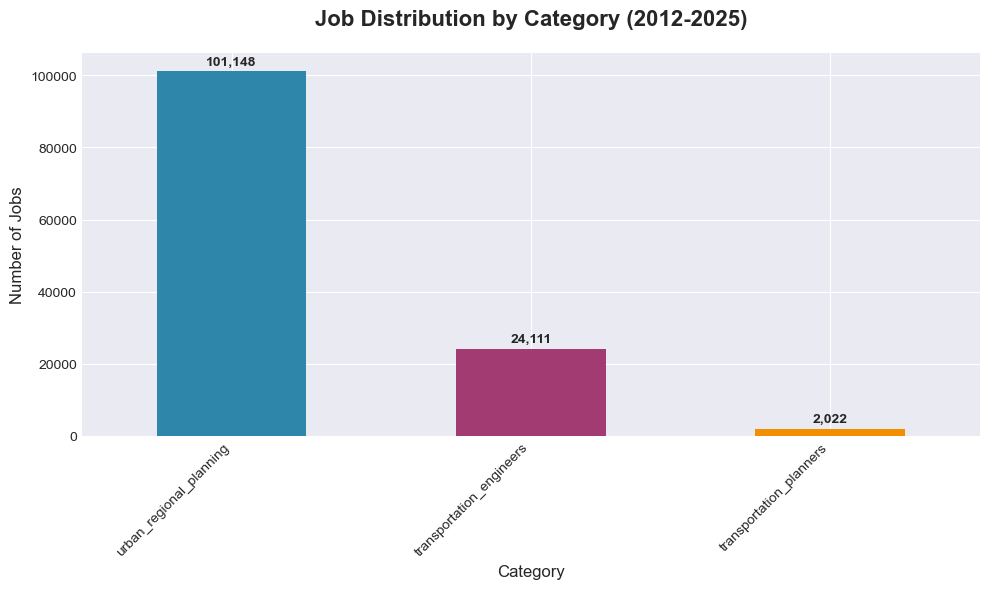

In [15]:
# Creating results foloder to save the plots in our local repository
Path('results/week2').mkdir(parents=True, exist_ok=True)

# Chart 1: Category distribution
plt.figure(figsize=(10, 6))
category_counts = df['category'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01']

ax = category_counts.plot(kind='bar', color=colors)
plt.title('Job Distribution by Category (2012-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Adding value labels on bars
for i, v in enumerate(category_counts):
    ax.text(i, v + 1000, f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('results/week2/01_jobs_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 1: Bar Chart — Category Distribution
The first chart shows how the 127,281 job postings are split across the three job categories. The bar chart makes it clear that the dataset is very unbalanced:

Urban/Regional Planners: 101,148 jobs (79.5%)

Transportation Engineers: 24,111 jobs (18.9%)

Transportation Planners: 2,022 jobs (1.6%)

## Insight:  
Urban/regional planning dominates the dataset, likely because this category is broader and includes many different job titles and O*NET codes. On the other hand, transportation planners are a much more specialized group, so they appear far less often. This imbalance matters for later comparisons (and especially for any machine learning), because models can get biased toward the largest class. To handle this, we may need approaches like stratified sampling or class weighting so the smaller groups aren’t ignored.

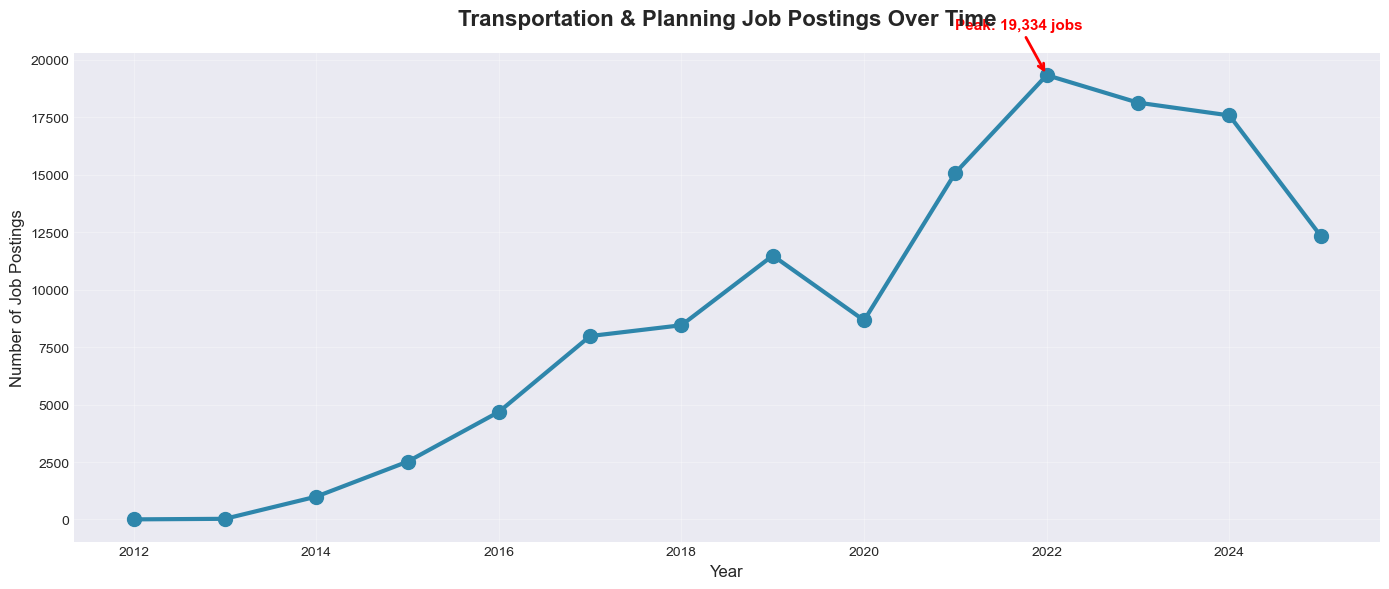

✓ Chart 2 saved


In [16]:
# Chart 2: Temporal trends
df['year'] = pd.to_datetime(df['created']).dt.year
jobs_by_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(jobs_by_year.index, jobs_by_year.values, marker='o', linewidth=3, 
         markersize=10, color='#2E86AB')

plt.title('Transportation & Planning Job Postings Over Time', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Job Postings', fontsize=12)
plt.grid(True, alpha=0.3)

# Adding annotations for interesting points
max_year = jobs_by_year.idxmax()
max_jobs = jobs_by_year.max()
plt.annotate(f'Peak: {max_jobs:,} jobs', 
             xy=(max_year, max_jobs), 
             xytext=(max_year-1, max_jobs+2000),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('results/week2/02_jobs_over_time.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart 2 saved")

## Chart 2: Line Chart — Overall Temporal Trend
The second chart shows the total number of job postings each year from 2012 to 2025. Overall, the pattern looks like steady growth over time. Job postings were fairly low in 2012–2014 (less than 5,000 per year), then they increased gradually through the mid-2010s and reached the highest point in 2021, with 19,334 postings. After 2021, there’s a small drop in 2022–2023, and then the numbers seem to rise again in 2024.

## Insight: 
The peak in 2021 may be connected to post-COVID hiring, where more projects and policies (like infrastructure planning and remote work changes) increased the need for planning and engineering roles. The slight dip after that could just reflect the job market settling back down. Also, the 2025 numbers look incomplete (only through September), so we shouldn’t treat the lower count in 2025 as a real decline.

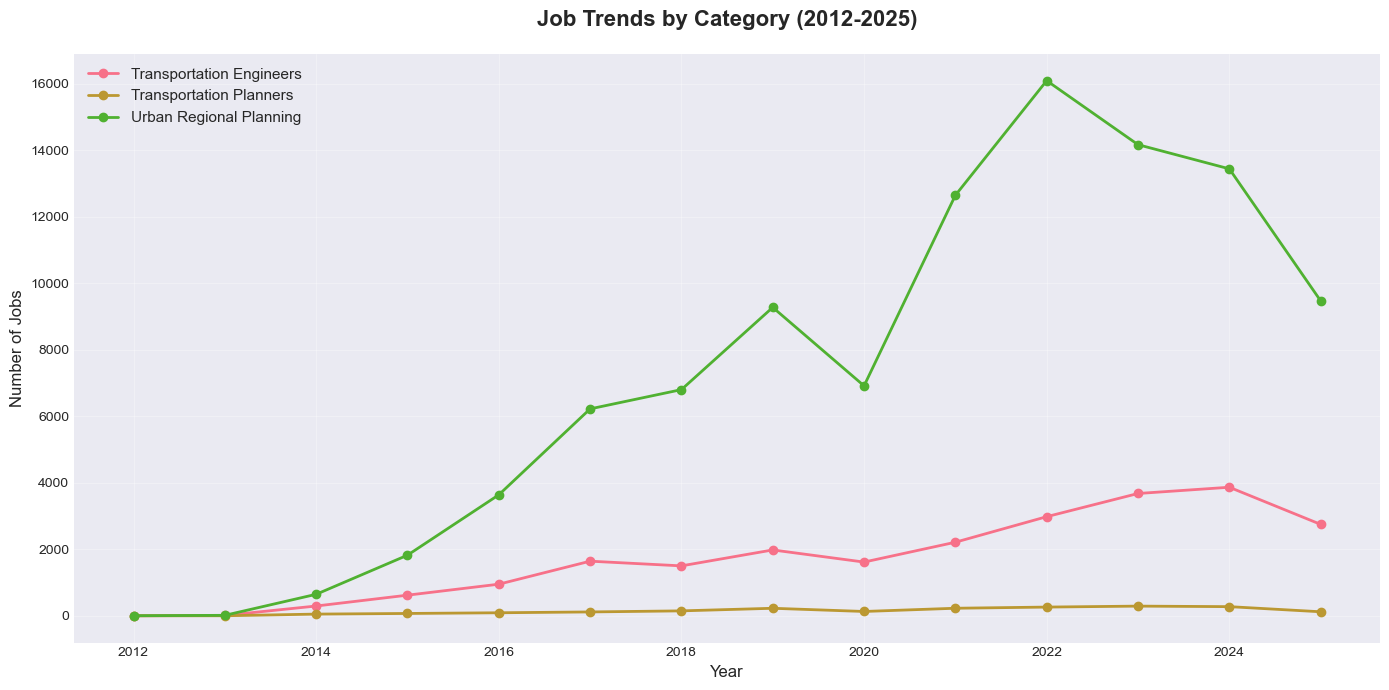

In [17]:
# Chart 3: Multi-line trends
pivot_data = df.groupby(['year', 'category']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
for category in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[category], 
             marker='o', linewidth=2, markersize=6,
             label=category.replace('_', ' ').title())

plt.title('Job Trends by Category (2012-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/week2/03_category_trends.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 3: Multi-Line Chart — Trends by Category
The third chart breaks the yearly trend down by each category, with separate lines for transportation engineers, transportation planners, and urban/regional planners. The urban/regional planning line mostly shapes the overall trend, and it rises and peaks around 2021–2022, similar to what we saw in the total count. Transportation engineers show a more gradual and steady increase over time, without a huge spike. Transportation planners stay almost flat across the years, usually sitting between 100 and 300 postings per year.

## Insight: 
These differences suggest that outside influences (like infrastructure funding, city development, and planning policies) may impact urban/regional planning jobs more strongly because it’s a broader category. Transportation engineering demand seems more consistent, possibly because it is tied to ongoing infrastructure work and maintenance rather than policy changes. The fact that transportation planners barely change over time again highlights that this role is very niche in the overall job market.

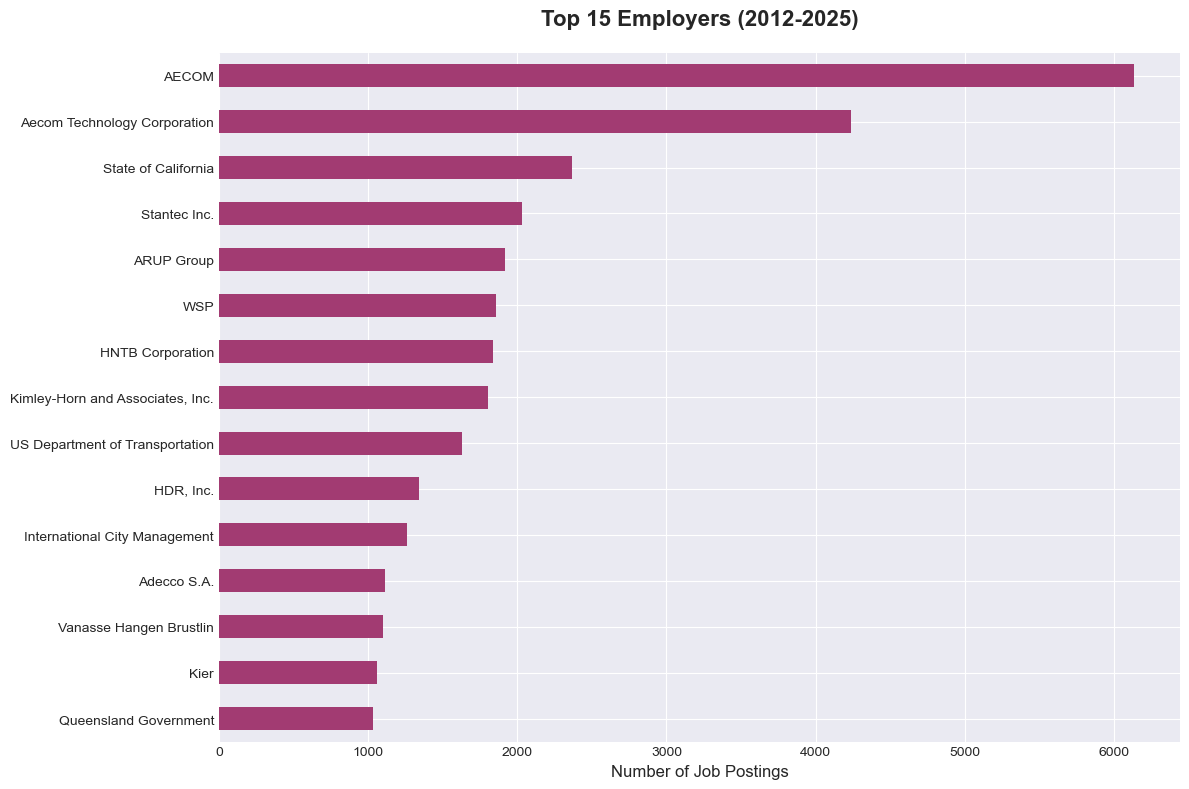

In [18]:
# Chart 4: Top companies
top_companies = df['company_name'].value_counts().head(15)

plt.figure(figsize=(12, 8))
top_companies.plot(kind='barh', color='#A23B72')
plt.title('Top 15 Employers (2012-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('results/week2/04_top_companies.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 4: Horizontal Bar Chart — Top 15 Companies
The fourth chart shows the companies that posted the most jobs in the dataset. AECOM was the top employer with about 6,137 postings, followed by Aecom Technology Corporation with 4,237 postings. These two names are probably the same company written in different ways, and if we combine them, AECOM would have 10,000+ postings in total. Other major employers in the top list include the State of California (2,366), Stantec Inc. (2,029), ARUP Group (1,917), WSP (1,859), HNTB Corporation (1,835), and Kimley-Horn and Associates (1,804). The U.S. Department of Transportation also shows up with 1,631 postings, which stands out as one of the largest government employers.

## Insight: 
Most of the top employers are big engineering and consulting firms (like AECOM, Stantec, WSP, HNTB, Kimley-Horn, HDR), along with a few government agencies. This suggests that transportation planning and engineering jobs are mostly concentrated within a smaller group of major companies and public-sector organizations. Also, the duplicate AECOM entries point to a data cleaning issue—standardizing company names would be a useful preprocessing step for future analysis.

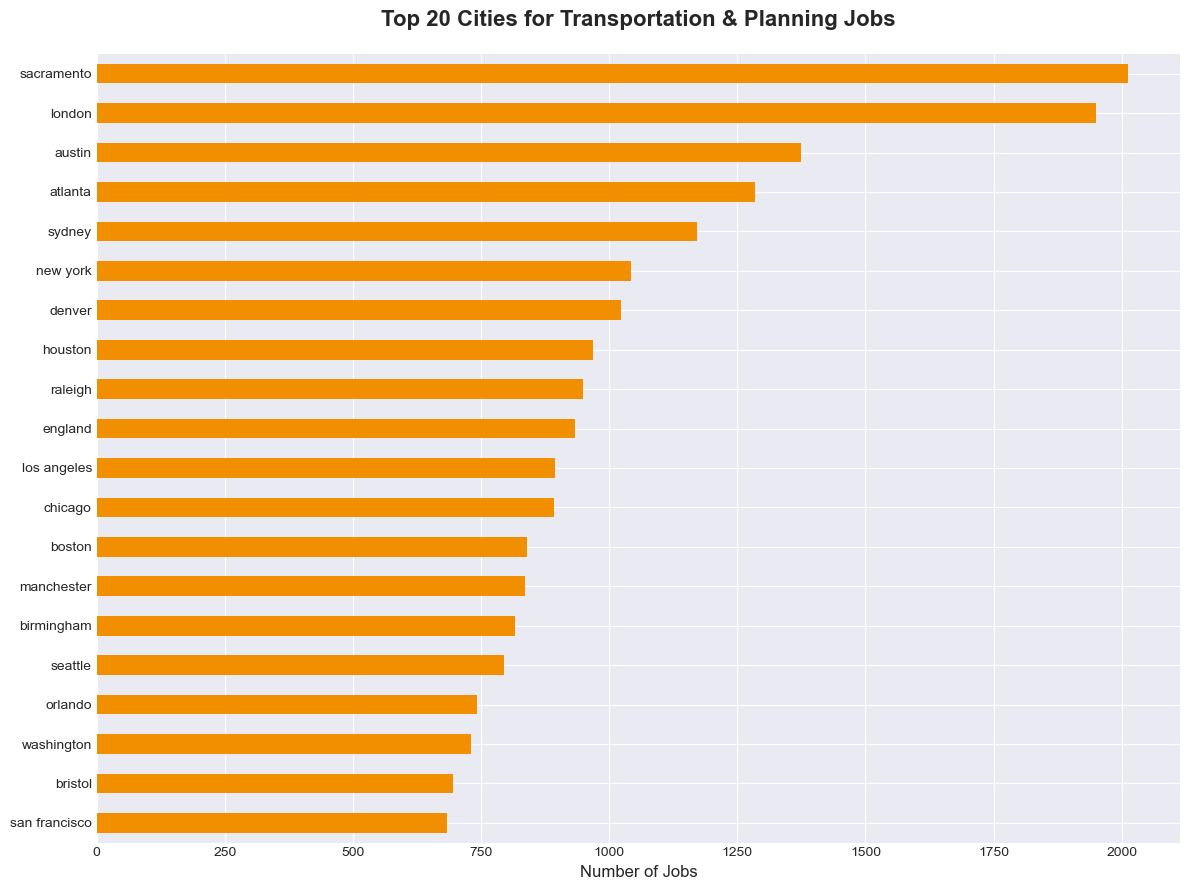

In [19]:
# Chart 5: Geographic distribution
top_cities = df['city'].value_counts().head(20)

plt.figure(figsize=(12, 9))
top_cities.plot(kind='barh', color='#F18F01')
plt.title('Top 20 Cities for Transportation & Planning Jobs', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('results/week2/05_top_cities.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 5: Horizontal Bar Chart — Top 20 Cities
The fifth chart highlights the top 20 cities with the most job postings. Sacramento ranked first with 2,013 postings, followed by London (1,949), Austin (1,374), Atlanta (1,284), and Sydney (1,171). Overall, the list includes a mix of major U.S. cities (like New York, Denver, Houston, Raleigh, Los Angeles, Chicago, Boston, Seattle, Orlando, Washington, and San Francisco) as well as international cities (such as London, Sydney, Manchester, Birmingham, and Bristol). This shows the dataset is not limited to the U.S.—it has a noticeable global reach.

## Insight: 
The appearance of several UK cities (London, Manchester, Birmingham, Bristol) and Sydney suggests the dataset includes strong coverage outside the U.S., especially in English-speaking countries. One data issue to note is that “england” shows up as a “city” with 934 entries, which likely means there are some location-formatting or parsing errors that we should clean up later.

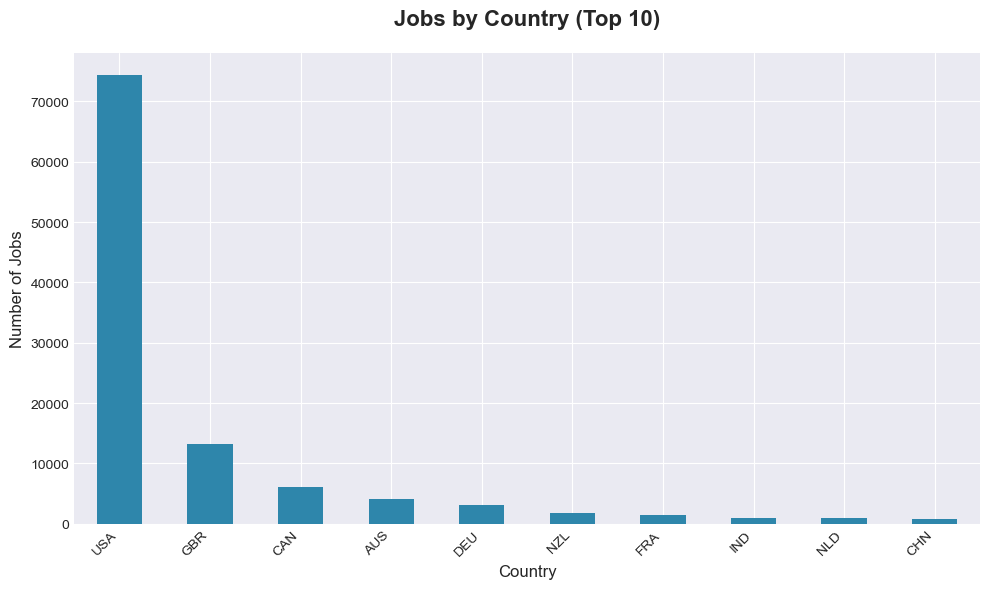

In [11]:
# Chart 6: Top 10 countries
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='#2E86AB')
plt.title('Jobs by Country (Top 10)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/week2/06_countries.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 6: Bar Chart — Top 10 Countries
The sixth chart shows how job postings are distributed across countries. The United States clearly has the most postings, with 74,309 jobs (58.4%). After that, the largest contributors are the United Kingdom (13,148 / 10.3%), Canada (6,018 / 4.7%), Australia (4,127 / 3.2%), and Germany (3,145 / 2.5%). In total, the dataset includes postings from 134 countries, but many of those countries only appear a small number of times.

## Insight: 
It makes sense that the dataset is mostly U.S.-focused, since LinkUp mainly collects job data from the U.S. At the same time, the strong presence of the UK, Canada, and Australia means we can still do useful comparisons across English-speaking countries. Even though Germany and other European countries have fewer postings, they still add value by letting us explore whether job demand and workforce needs look different in other regions.

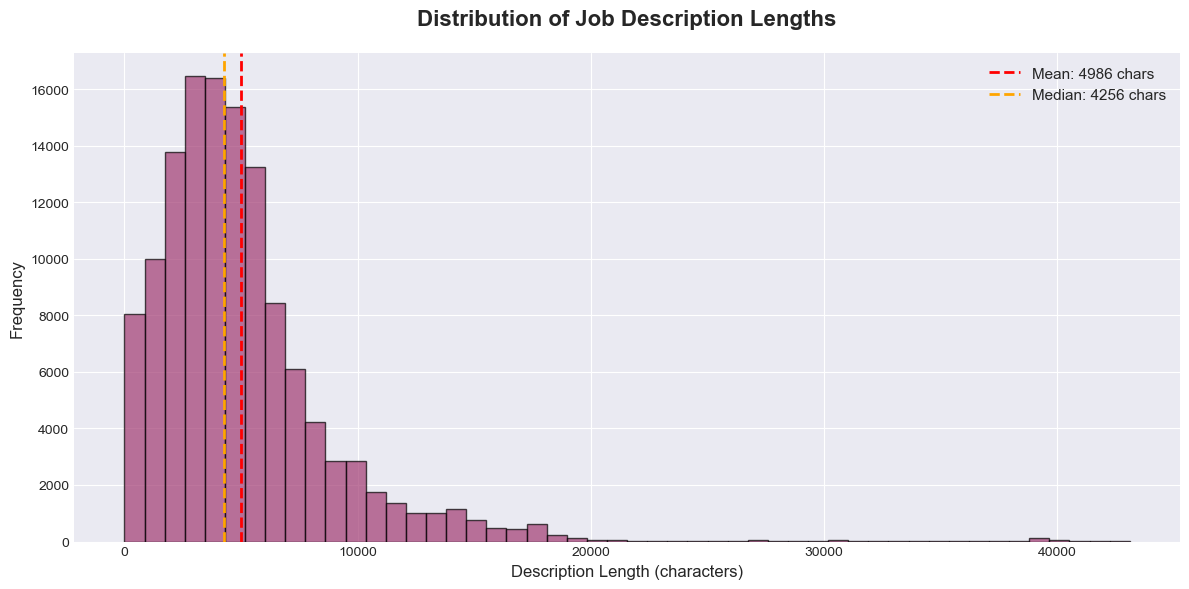

In [20]:
# Chart 7: Description lengths
desc_lengths = df['job_description'].str.len()

plt.figure(figsize=(12, 6))
plt.hist(desc_lengths, bins=50, color='#A23B72', alpha=0.7, edgecolor='black')
plt.axvline(desc_lengths.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {desc_lengths.mean():.0f} chars')
plt.axvline(desc_lengths.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {desc_lengths.median():.0f} chars')
plt.title('Distribution of Job Description Lengths', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Description Length (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('results/week2/07_description_lengths.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 7: Histogram — Description Length
The last chart is a histogram showing how long the job descriptions are (measured in number of characters). The distribution is right-skewed, meaning most descriptions are in a normal range, but a few are extremely long. The average (mean) description length is about 4,986 characters, and the middle value (median) is 4,256 characters. Most descriptions fall between 1,000 and 10,000 characters, but there are some very long ones going all the way up to 43,122 characters. The chart also marks the mean and median using dashed vertical lines.

## Insight: 
A typical length of around 4,000–5,000 characters (roughly 600–800 words) is actually pretty good for text-based analysis, like skill extraction, topic modeling, or keyword frequency. The right-skew suggests that some postings include a lot of extra content (like benefits, company background, or legal disclaimers), which makes them much longer than normal. On the other side, a few descriptions are extremely short (the minimum is 1 character), which likely means they are low-quality or incomplete records. For future analysis, it could help to remove these by setting a minimum length cutoff (for example, 100–200 characters) to filter out “stub” postings.